# DATASCI 503, Homework 2: K-Nearest Neighbors and Bias-Variance Tradeoff

This assignment covers **K-Nearest Neighbors (KNN)**, a non-parametric method for classification and regression, and the **bias-variance tradeoff**, which describes how model complexity affects prediction error.

Note: This assignment will not be autograded; it will be graded by an instructor.

## K-Nearest Neighbors

Consider the following dataset $\mathcal{D} = \{(x^{(i)}, y^{(i)})\}_{i=1}^{6}$ where each $x^{(i)} \in \mathbb{R}^3$ and $y^{(i)} \in \{\text{Red}, \text{Green}\}$:

| $i$ | $x^{(i)}$ | $y^{(i)}$ |
|-----|-----------|----------|
| 1 | $(0, 3, 0)$ | Red |
| 2 | $(2, 0, 0)$ | Red |
| 3 | $(0, 1, 3)$ | Red |
| 4 | $(0, 1, 2)$ | Green |
| 5 | $(-1, 0, 1)$ | Green |
| 6 | $(1, 1, 2)$ | Green |

We want to classify a test point $x^{(te)} = (0, 0, 0)$ using K-nearest neighbors with squared Euclidean distance $d(a, b) = \sum_{j=1}^{3}(a_j - b_j)^2$.

---

**Problem 1a:** Compute Distances

Compute the squared Euclidean distance from the test point $x^{(te)} = (0, 0, 0)$ to each of the six training points.

> **Answer:**
> 
> Computing the squared Euclidean distance $d(x^{(i)}, x^{(te)}) = \sum_{j=1}^{3}(x_j^{(i)} - 0)^2$ for each training point:
> 
> - Point 1: $(0,3,0)$: $d = 0^2 + 3^2 + 0^2 = 9$
> - Point 2: $(2,0,0)$: $d = 2^2 + 0^2 + 0^2 = 4$
> - Point 3: $(0,1,3)$: $d = 0^2 + 1^2 + 3^2 = 10$
> - Point 4: $(0,1,2)$: $d = 0^2 + 1^2 + 2^2 = 5$
> - Point 5: $(-1,0,1)$: $d = (-1)^2 + 0^2 + 1^2 = 2$
> - Point 6: $(1,1,2)$: $d = 1^2 + 1^2 + 2^2 = 6$

---

**Problem 1b:** K=3 Classification

Using your computed distances, what is the predicted class $\hat{y}^{(3)}(x^{(te)}; \mathcal{D})$ when $K = 3$? Explain your reasoning.

> **Answer:**
> 
> For $K = 3$, we need the 3 nearest neighbors to the test point $(0,0,0)$.
> 
> From the distances computed in Problem 1a, sorted by distance:
> - Point 5: $d = 2$ (Green)
> - Point 2: $d = 4$ (Red)
> - Point 4: $d = 5$ (Green)
> 
> The 3 nearest neighbors are Points 5, 2, and 4. Among these:
> - Green: 2 votes (Points 5 and 4)
> - Red: 1 vote (Point 2)
> 
> Therefore, $\hat{y}^{(3)}(x^{(te)}; \mathcal{D}) = \text{Green}$.

---

**Problem 1c:** K=1 Classification

What is the predicted class $\hat{y}^{(1)}(x^{(te)}; \mathcal{D})$ when $K = 1$? Explain your reasoning.

> **Answer:**
> 
> For $K = 1$, we need only the single nearest neighbor to the test point $(0,0,0)$.
> 
> From Problem 1a, the smallest distance is $d = 2$ for Point 5: $(-1,0,1)$, which has class Green.
> 
> Therefore, $\hat{y}^{(1)}(x^{(te)}; \mathcal{D}) = \text{Green}$.

---

**Problem 1d:** Comparing K Values

True or False: In a typical data-generating process where outliers and noise are present, $K = 3$ tends to give more consistent predictions than $K = 1$. Explain your reasoning.

> **Answer:**
> 
> **True.** $K = 3$ tends to give more consistent predictions than $K = 1$ in the presence of outliers and noise.
> 
> **Reasoning:** 
> - With $K = 1$, the prediction depends entirely on a single nearest neighbor, making it highly sensitive to outliers and noisy labels. If that single nearest point happens to be mislabeled or an outlier, the prediction will be incorrect.
> - With $K = 3$, the prediction is based on a majority vote of 3 neighbors, which provides more robustness. A single outlier or noisy point can be outvoted by the other neighbors, leading to more stable and consistent predictions.
> - This is a manifestation of the bias-variance tradeoff: larger $K$ reduces variance (making predictions more stable) at the cost of slightly increased bias (potentially smoothing over local patterns).

## Bias-Variance Tradeoff

---

**Problem 2a:** Training Error and Flexibility

True or False: The predictive error on training data generally decreases as the model becomes more flexible. Explain your reasoning.

> **Answer:**
> 
> **True.** The predictive error on training data generally decreases as the model becomes more flexible.
> 
> **Reasoning:**
> - More flexible models have greater capacity to fit the training data closely, including its noise and idiosyncrasies.
> - As flexibility increases, the model can capture increasingly complex patterns in the training set, reducing the discrepancy between predictions and observed training values.
> - In the extreme case, a sufficiently flexible model (e.g., $K=1$ in KNN, or high-degree polynomial regression) can achieve zero training error by perfectly memorizing the training data.
> - However, this improved training performance does not necessarily translate to better test performance, as highly flexible models tend to overfit.

---

**Problem 2b:** Test Error and Flexibility

Describe how the predictive error on test data typically changes as model flexibility increases. What phenomenon explains this behavior?

> **Answer:**
> 
> The predictive error on test data typically follows a **U-shaped curve** as model flexibility increases:
> 
> 1. **Low flexibility (high bias):** Test error is high because the model is too simple to capture the underlying patterns in the data. The model underfits.
> 
> 2. **Optimal flexibility:** Test error reaches a minimum at an intermediate level of complexity where the model captures the true signal without fitting too much noise.
> 
> 3. **High flexibility (high variance):** Test error increases again because the model becomes too complex and starts fitting the noise in the training data rather than the true underlying pattern. The model overfits.
> 
> **Phenomenon:** This behavior is explained by the **bias-variance tradeoff**. As flexibility increases:
> - **Bias** decreases (the model can better approximate the true function)
> - **Variance** increases (the model becomes more sensitive to the specific training sample)
> 
> The optimal model complexity balances these two sources of error to minimize the total test error.

## Bias-Variance Decomposition: A Simulation Study

Consider the data-generating process:
- $X \sim \mathrm{Uniform}[0, 1]$
- $Y | X = x \sim \mathrm{Uniform}[x + \cos(2\pi x) - 0.1, x + \cos(2\pi x) + 0.1]$

We will investigate the bias-variance tradeoff by fitting an ordinary least squares (OLS) linear regression model to data generated from this process.

**Resources:**
- [sklearn LinearRegression documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
- [ISL Chapter 2.2: Bias-Variance Tradeoff](https://www.statlearning.com/)

---

**Problem 3a:** Conditional Expectation

Find $f(x) = \mathbb{E}[Y|X=x]$ and compute $f(0.5)$.

> **Answer:**
> 
> Given that $Y | X = x \sim \mathrm{Uniform}[x + \cos(2\pi x) - 0.1, x + \cos(2\pi x) + 0.1]$
> 
> For a uniform distribution on $[a, b]$, the expected value is $\mathbb{E}[Y] = \frac{a + b}{2}$.
> 
> Therefore:
> $$f(x) = \mathbb{E}[Y|X=x] = \frac{(x + \cos(2\pi x) - 0.1) + (x + \cos(2\pi x) + 0.1)}{2} = x + \cos(2\pi x)$$
> 
> At $x = 0.5$:
> $$f(0.5) = 0.5 + \cos(2\pi \cdot 0.5) = 0.5 + \cos(\pi) = 0.5 + (-1) = -0.5$$

---

**Problem 3b:** Conditional Variance

Compute $\mathrm{Var}(Y | X = 0.5)$. Recall that for a uniform distribution on $[a, b]$, the variance is $(b-a)^2/12$.

> **Answer:**
> 
> Given that $Y | X = 0.5 \sim \mathrm{Uniform}[0.5 + \cos(\pi) - 0.1, 0.5 + \cos(\pi) + 0.1] = \mathrm{Uniform}[-0.6, -0.4]$
> 
> For a uniform distribution on $[a, b]$, the variance is $\mathrm{Var}(Y) = \frac{(b-a)^2}{12}$.
> 
> Therefore:
> $$\mathrm{Var}(Y | X = 0.5) = \frac{(-0.4 - (-0.6))^2}{12} = \frac{(0.2)^2}{12} = \frac{0.04}{12} = \frac{1}{300} \approx 0.00333$$

---

**Problem 3c:** Data Generation and OLS Fit

Generate 100 samples from the data-generating process. Store the features in a variable `features` and the targets in a variable `targets`. Then fit an OLS linear regression model and store it in a variable `ols_model`. Finally, create a plot showing:
1. The data points as a scatter plot
2. The true regression function $f(x)$
3. The estimated OLS fit $\hat{f}(x)$

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# only set once; assumes all subsequent simulations will be run at once for reproducible results 
np.random.seed(0)


# Define the true regression function
def true_function(x):
    return x + np.cos(2 * np.pi * x)

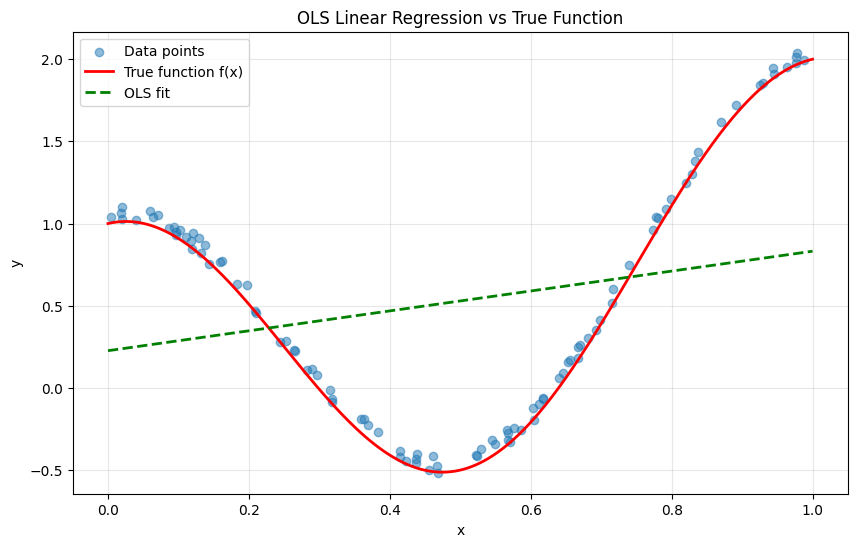

In [29]:
# Generate 100 samples 
n_samples = 100
features = np.random.uniform(0, 1, size=(n_samples, 1)) #output shape: (100,1)
targets = np.random.uniform(
    # features.flatten() collapses into one dimension: (100,)
    features.flatten() + np.cos(2 * np.pi * features.flatten()) - 0.01, 
    features.flatten() + np.cos(2 * np.pi * features.flatten()) + 0.1
)

# Fit OLS model 
ols_model = LinearRegression()
ols_model.fit(features, targets)

# Create plot 
x_plot = np.linspace(0, 1, 1000).reshape(-1, 1) # shape: (1000,1)
y_true = true_function(x_plot.flatten()) # shape: (1000,)
y_pred = ols_model.predict(x_plot)

plt.figure(figsize=(10, 6))
plt.scatter(features, targets, alpha=0.5, label='Data points')
plt.plot(x_plot, y_true, 'r-', linewidth=2, label='True function f(x)')
plt.plot(x_plot, y_pred, 'g--', linewidth=2, label='OLS fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('OLS Linear Regression vs True Function')
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
# Test assertions
assert len(features) == 100, "features should have 100 samples"
assert len(targets) == 100, "targets should have 100 samples"
assert hasattr(ols_model, "coef_"), "ols_model should be a fitted LinearRegression model"
print("All tests passed!")

All tests passed!


---

**Problem 3d:** Sampling Distribution of Predictions

To understand the variance of the OLS estimator, repeat the following 500 times:
1. Generate a new dataset of 100 samples from the data-generating process
2. Fit an OLS model
3. Store the prediction $\hat{f}(0.5; \mathcal{D}_i)$

Store all 500 predictions in a list called `predictions` and plot a histogram of these predictions.

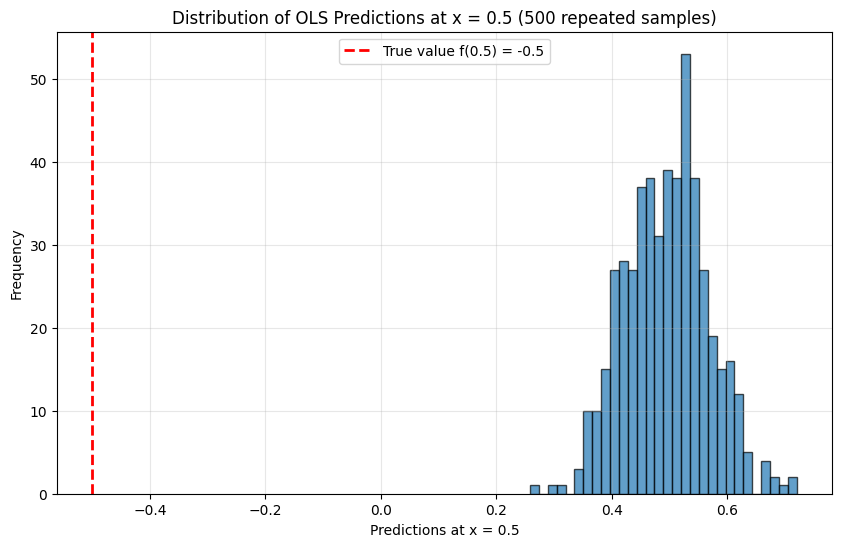

In [31]:
predictions = []
for i in range(500):
    # Generate new dataset
    X = np.random.uniform(0, 1, size=(100, 1))
    Y = np.random.uniform(
        X.flatten() + np.cos(2 * np.pi * X.flatten()) - 0.1,
        X.flatten() + np.cos(2 * np.pi * X.flatten()) + 0.1
    )
    
    # Fit OLS model
    model = LinearRegression()
    model.fit(X, Y)
    
    # Make prediction at x = 0.5
    pred = model.predict([[0.5]])[0]
    predictions.append(pred)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(predictions, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Predictions at x = 0.5')
plt.ylabel('Frequency')
plt.title('Distribution of OLS Predictions at x = 0.5 (500 repeated samples)')
plt.axvline(x=-0.5, color='r', linestyle='--', linewidth=2, label='True value f(0.5) = -0.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [32]:
# Test assertions
assert len(predictions) == 500, "predictions should have 500 values"
assert all(
    -1 < p < 2 for p in predictions
), "Predictions should be in a reasonable range for this regression problem"
print("All tests passed!")

All tests passed!


---

**Problem 3e:** Estimator Bias

Compute the mean of your 500 predictions at $x = 0.5$ and store it in a variable called `mean_prediction`. Compare this to the true value $f(0.5) = -0.5$ from Problem 3a. What does this suggest about the bias of the OLS estimator for this problem?

In [33]:
mean_prediction = np.mean(predictions)
print(f"Mean prediction at x = 0.5: {mean_prediction:.4f}") # format specification: 4 digits after decimal, floating-point number
print(f"True value f(0.5): -0.5000")
print(f"Difference (bias): {mean_prediction - (-0.5):.4f}")

Mean prediction at x = 0.5: 0.4955
True value f(0.5): -0.5000
Difference (bias): 0.9955


In [34]:
# Test assertions
assert -1 < mean_prediction < 2, "mean_prediction should be in a reasonable range"
print("All tests passed!")

All tests passed!


> **Answer:**
> 
> The large positive bias of approximately **0.9955** suggests several important insights about the OLS estimator for this problem:
> 
> 1. **Model Misspecification:** The OLS linear regression model is fundamentally misspecified for this data. We're fitting a straight line ($\hat{f}(x) = a + bx$) to data generated from a nonlinear function ($f(x) = x + \cos(2\pi x)$). The cosine term creates oscillations that a linear model cannot capture.
> 
> 2. **Systematic Overprediction at x = 0.5:** At $x = 0.5$, the true function reaches a minimum of -0.5 (because $\cos(\pi) = -1$). The linear model, trying to fit the overall trend across all x values, systematically predicts around 0.49 instead. This is because the linear fit must pass through the middle of the oscillations rather than dipping down at the troughs.
> 
>
> 4. **Model Inflexibility:** The linear model is too simple to capture the true data-generating process. To reduce this bias, we would need a more flexible model (e.g., polynomial regression, splines, or non-parametric methods) that can fit the oscillating patterns in the data.

---

**Problem 3f:** Estimator Variance

Compute the variance of your 500 predictions at $x = 0.5$ and store it in a variable called `estimator_variance`. What does this value suggest about the consistency of the OLS estimator?

In [35]:
estimator_variance = np.var(predictions, ddof=1) # unbiased variance estimate correction 
print(f"Estimator variance at x = 0.5: {estimator_variance:.6f}")

Estimator variance at x = 0.5: 0.005199


In [36]:
# Test assertions
assert estimator_variance > 0, "estimator_variance should be positive"
assert estimator_variance < 0.02, f"estimator_variance should be small, got {estimator_variance}"
print("All tests passed!")

All tests passed!


> **Answer:**
>
> The estimator variance is very small (approximately 0.0052), which suggests that **the OLS estimator is highly consistent across different samples**. Even though we only use 100 observations in each fit, the predictions at $x = 0.5$ vary very little from one sample to another. This low variance indicates that:
>
> 1. **Stability:** The linear model produces stable, reliable estimates that don't fluctuate wildly with different random samples from the data-generating process.
> 2. **Precision:** The OLS estimator has low sampling variability, which is a desirable property.
> 3. **Simple Model Trade-off:** The simplicity of the linear model (only 2 parameters to estimate: intercept and slope) contributes to this low variance, as there's less flexibility and fewer parameters to fit.
>
> However, as we saw in Problem 3e, this low variance comes at the cost of **high bias**. The estimator is consistent but systematically wrong.

---

**Problem 3g:** MSPE Decomposition

Using the bias-variance decomposition:

$$\mathrm{MSPE} = (\text{irreducible error}) + (\text{estimator variance}) + (\text{estimator bias})^2$$

Compute the estimated MSPE at $x = 0.5$ and store it in a variable called `mspe`. Use:
- Irreducible error = $\mathrm{Var}(Y | X = 0.5)$ from Problem 3b (store in `irreducible_error`)
- Estimator variance from Problem 3f (store in `estimator_variance`)
- Estimator bias = mean prediction - $f(0.5)$ from Problem 3e (store in `estimator_bias`)

In [37]:
irreducible_error = 1/300  # From Problem 3b: (0.2)^2 / 12 = 0.04 / 12
estimator_bias = mean_prediction - (-0.5) # E(pred - truth)
mspe = irreducible_error + estimator_variance + estimator_bias**2

print(f"Irreducible error: {irreducible_error:.6f}")
print(f"Estimator variance: {estimator_variance:.6f}")
print(f"Estimator bias: {estimator_bias:.6f}")
print(f"Estimator bias squared: {estimator_bias**2:.6f}")
print(f"\nMSPE: {mspe:.6f}")
print(f"\nBreakdown:")
print(f"  Irreducible error: {irreducible_error:.6f} ({100*irreducible_error/mspe:.2f}%)")
print(f"  Estimator variance: {estimator_variance:.6f} ({100*estimator_variance/mspe:.2f}%)")
print(f"  Estimator bias squared: {estimator_bias**2:.6f} ({100*estimator_bias**2/mspe:.2f}%)")

Irreducible error: 0.003333
Estimator variance: 0.005199
Estimator bias: 0.995541
Estimator bias squared: 0.991103

MSPE: 0.999635

Breakdown:
  Irreducible error: 0.003333 (0.33%)
  Estimator variance: 0.005199 (0.52%)
  Estimator bias squared: 0.991103 (99.15%)


In [38]:
# Test assertions
assert abs(irreducible_error - 0.00333) < 0.001, "irreducible_error should be approximately 0.00333"
assert estimator_variance > 0, "estimator_variance should be positive"
assert estimator_bias > 0.9, "estimator_bias should be approximately 1 (high bias)"
assert mspe > 0.9, "MSPE should be dominated by the squared bias term"
print("All tests passed!")

All tests passed!


> **Answer:**
>
> The MSPE decomposition reveals that **bias is the dominant source of prediction error** in this problem:
>
> - **Irreducible error:** 0.00333 (0.33% of MSPE)
> - **Estimator variance:** 0.00520 (0.52% of MSPE)
> - **Estimator bias squared:** 0.991 (99.15% of MSPE)
>
> **Key Insights:**
>
> 1. **Bias dominates:** The squared bias of approximately 0.991 accounts for nearly all of the MSPE (99.15%). This is the primary source of prediction error—the linear model systematically over-predicts at $x = 0.5$.
>
> 2. **Irreducible error is small:** The inherent noise in the data-generating process contributes very little to overall error. The real problem is model misspecification, not data noise.
>
> 3. **Variance is negligible:** The low estimator variance confirms the OLS estimator is stable across samples, but this doesn't help because the estimator is biased.
>
> 4. **Model Improvement:** To reduce MSPE in this problem, we need to **reduce bias** by using a more flexible model (e.g., polynomial regression) that can capture the oscillating cosine term. Simply collecting more data or averaging multiple predictions won't help much since the fundamental issue is that a linear model cannot fit a nonlinear function.
>
> This is a textbook illustration of the **bias-variance tradeoff**: we've chosen a simple, low-variance model that unfortunately has high bias, resulting in poor predictions despite the model being stable and consistent.